In [1]:
# Install libraries if not available
# !pip install pandas numpy pydataset matplotlib

import pandas as pd
import numpy as np
from pydataset import data

# Load directly from pydataset
df = data('airquality')

In [2]:
# Showing the shape (rows, columns)
print("Shape of the dataset:", df.shape)

# Listing column names and dtypes
print("\nColumn Names and Data Types:")
print(df.dtypes)

# Displaying the first 5 and last 5 rows
print("\nFirst 5 rows:")
print(df.head(5))

print("\nLast 5 rows:")
print(df.tail(5))

# Info Summary
print("\nDataset Info Summary:")
df.info()

Shape of the dataset: (153, 6)

Column Names and Data Types:
Ozone      float64
Solar.R    float64
Wind       float64
Temp         int64
Month        int64
Day          int64
dtype: object

First 5 rows:
   Ozone  Solar.R  Wind  Temp  Month  Day
1   41.0    190.0   7.4    67      5    1
2   36.0    118.0   8.0    72      5    2
3   12.0    149.0  12.6    74      5    3
4   18.0    313.0  11.5    62      5    4
5    NaN      NaN  14.3    56      5    5

Last 5 rows:
     Ozone  Solar.R  Wind  Temp  Month  Day
149   30.0    193.0   6.9    70      9   26
150    NaN    145.0  13.2    77      9   27
151   14.0    191.0  14.3    75      9   28
152   18.0    131.0   8.0    76      9   29
153   20.0    223.0  11.5    68      9   30

Dataset Info Summary:
<class 'pandas.core.frame.DataFrame'>
Index: 153 entries, 1 to 153
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    

In [3]:
# Produce descriptive statistics for numeric columns
print("Descriptive Statistics:")
print(df.describe())

Descriptive Statistics:
            Ozone     Solar.R        Wind        Temp       Month         Day
count  116.000000  146.000000  153.000000  153.000000  153.000000  153.000000
mean    42.129310  185.931507    9.957516   77.882353    6.993464   15.803922
std     32.987885   90.058422    3.523001    9.465270    1.416522    8.864520
min      1.000000    7.000000    1.700000   56.000000    5.000000    1.000000
25%     18.000000  115.750000    7.400000   72.000000    6.000000    8.000000
50%     31.500000  205.000000    9.700000   79.000000    7.000000   16.000000
75%     63.250000  258.750000   11.500000   85.000000    8.000000   23.000000
max    168.000000  334.000000   20.700000   97.000000    9.000000   31.000000


In [4]:
# For each column, show number of unique values
print("\nUnique values per column:")
print(df.nunique())


Unique values per column:
Ozone       67
Solar.R    117
Wind        31
Temp        40
Month        5
Day         31
dtype: int64


In [5]:
# Count missing values per column
print("Missing values count per column:")
print(df.isna().sum())

Missing values count per column:
Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64


In [6]:
# Create a copy df_mv where you impute
df_mv = df.copy()

In [7]:
# Ozone: fill with the column median (numeric)
ozone_median = df_mv['Ozone'].median()
df_mv['Ozone'] = df_mv['Ozone'].fillna(ozone_median)

In [8]:
# Solar.R: fill with the column mean (numeric)
solar_mean = df_mv['Solar.R'].mean()
df_mv['Solar.R'] = df_mv['Solar.R'].fillna(solar_mean)

In [9]:
print("\nMissing values after imputation:")
print(df_mv.isna().sum())


Missing values after imputation:
Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64


In [10]:
# Select the columns: Ozone, Solar.R, Temp into a new DataFrame df_sel
df_sel = df[['Ozone', 'Solar.R', 'Temp']]

In [11]:
# Select the first 10 rows of df_sel
df_first_10 = df_sel.iloc[:10]
print("First 10 rows of selected columns:")
print(df_first_10)

First 10 rows of selected columns:
    Ozone  Solar.R  Temp
1    41.0    190.0    67
2    36.0    118.0    72
3    12.0    149.0    74
4    18.0    313.0    62
5     NaN      NaN    56
6    28.0      NaN    66
7    23.0    299.0    65
8    19.0     99.0    59
9     8.0     19.0    61
10    NaN    194.0    69


In [12]:
# Select rows where Month is May (5) or June (6) only
df_may_june = df[df['Month'].isin([5, 6])]
print("\nRows corresponding to May and June (Shape):", df_may_june.shape)


Rows corresponding to May and June (Shape): (61, 6)


In [13]:
# Filter rows where Ozone > 100 and Temp >= 85
cond_high = df[(df['Ozone'] > 100) & (df['Temp'] >= 85)]
print("Rows with Ozone > 100 and Temp >= 85:")
print(cond_high)

Rows with Ozone > 100 and Temp >= 85:
     Ozone  Solar.R  Wind  Temp  Month  Day
86   108.0    223.0   8.0    85      7   25
99   122.0    255.0   4.0    89      8    7
101  110.0    207.0   8.0    90      8    9
121  118.0    225.0   2.3    94      8   29


In [14]:
# Filter rows where Solar.R is missing
cond_missing_solar = df[df['Solar.R'].isna()]
print("\nRows where Solar.R is missing:")
print(cond_missing_solar)


Rows where Solar.R is missing:
    Ozone  Solar.R  Wind  Temp  Month  Day
5     NaN      NaN  14.3    56      5    5
6    28.0      NaN  14.9    66      5    6
11    7.0      NaN   6.9    74      5   11
27    NaN      NaN   8.0    57      5   27
96   78.0      NaN   6.9    86      8    4
97   35.0      NaN   7.4    85      8    5
98   66.0      NaN   4.6    87      8    6


In [15]:
# Filter rows for July (7) with Ozone between 50 and 100 (inclusive)
cond_july_ozone = df[(df['Month'] == 7) & (df['Ozone'].between(50, 100))]
print("\nJuly rows with Ozone between 50 and 100 inclusive:")
print(cond_july_ozone)


July rows with Ozone between 50 and 100 inclusive:
    Ozone  Solar.R  Wind  Temp  Month  Day
66   64.0    175.0   4.6    83      7    5
68   77.0    276.0   5.1    88      7    7
69   97.0    267.0   6.3    92      7    8
70   97.0    272.0   5.7    92      7    9
71   85.0    175.0   7.4    89      7   10
79   61.0    285.0   6.3    84      7   18
80   79.0    187.0   5.1    87      7   19
81   63.0    220.0  11.5    85      7   20
85   80.0    294.0   8.6    86      7   24
88   52.0     82.0  12.0    86      7   27
89   82.0    213.0   7.4    88      7   28
90   50.0    275.0   7.4    86      7   29
91   64.0    253.0   7.4    83      7   30
92   59.0    254.0   9.2    81      7   31


In [16]:
# Sort the dataset by Ozone descending and Temp ascending (multi-column sort)
df_sorted_ozone_temp = df.sort_values(by=['Ozone', 'Temp'], ascending=[False, True])

In [17]:
# Sort the dataset by Month then Day to get chronological order
df_chronological = df.sort_values(by=['Month', 'Day'], ascending=[True, True])

In [18]:
# Check if there are any fully duplicated rows
print("Number of completely duplicate rows:", df.duplicated().sum())

Number of completely duplicate rows: 0


In [19]:
# Intentionally create a few duplicate rows into df_dup
# Duplicating the first 3 rows as requested
df_dup = pd.concat([df, df.head(3)], ignore_index=True)
print("Shape of df_dup after adding duplicates:", df_dup.shape)

Shape of df_dup after adding duplicates: (156, 6)


In [20]:
# Remove duplicates and report how many were removed
initial_count = len(df_dup)
df_cleaned = df_dup.drop_duplicates()
final_count = len(df_cleaned)

print(f"Removed {initial_count - final_count} duplicate rows. Cleaned dataset shape: {df_cleaned.shape}")

Removed 3 duplicate rows. Cleaned dataset shape: (153, 6)


In [21]:
# Create a new column Temp_C converting Fahrenheit to Celsius
# Formula: (F - 32) * 5/9
df['Temp_C'] = (df['Temp'] - 32) * 5 / 9

In [22]:
# Flag a new boolean column High_Ozone where Ozone > 100
df['High_Ozone'] = df['Ozone'] > 100

In [23]:
# Create a categorical column Temp_Band with labels: Cool (<75F), Warm (75-85F), Hot (>85F)
# Using pd.cut: bins are (-inf, 74.999...), [75, 85], (85, inf)
df['Temp_Band'] = pd.cut(
    df['Temp'], 
    bins=[-float('inf'), 74.999, 85, float('inf')], 
    labels=['Cool', 'Warm', 'Hot']
)

In [24]:
print(df[['Temp', 'Temp_C', 'Ozone', 'High_Ozone', 'Temp_Band']].head())

   Temp     Temp_C  Ozone  High_Ozone Temp_Band
1    67  19.444444   41.0       False      Cool
2    72  22.222222   36.0       False      Cool
3    74  23.333333   12.0       False      Cool
4    62  16.666667   18.0       False      Cool
5    56  13.333333    NaN       False      Cool


In [25]:
# Group by Month and compute mean Ozone, median Solar.R, and max Temp
agg_df = df.groupby('Month').agg(
    mean_Ozone=('Ozone', 'mean'),
    median_Solar_R=('Solar.R', 'median'),
    max_Temp=('Temp', 'max')
).reset_index()

print("Monthly Aggregations:")
print(agg_df)

Monthly Aggregations:
   Month  mean_Ozone  median_Solar_R  max_Temp
0      5   23.615385           194.0        81
1      6   29.444444           188.5        93
2      7   59.115385           253.0        92
3      8   59.961538           197.5        97
4      9   31.448276           192.0        93


In [26]:
# Within each Month, count how many days have Ozone > 80
# Summing the boolean condition converts True to 1 and False to 0
df['Ozone_above_80'] = df['Ozone'] > 80
ozone_days_count = df.groupby('Month')['Ozone_above_80'].sum().astype(int).reset_index(name='Days_Ozone_Above_80')

print("\nDays with Ozone > 80 per Month:")
print(ozone_days_count)


Days with Ozone > 80 per Month:
   Month  Days_Ozone_Above_80
0      5                    1
1      6                    0
2      7                    6
3      8                    7
4      9                    2


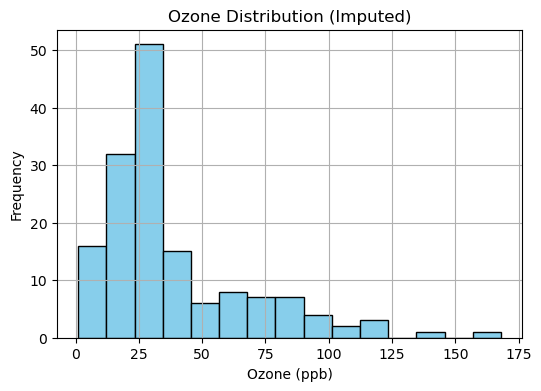

In [27]:
import matplotlib.pyplot as plt

# Histogram of 'Ozone' (after imputation, using 'df_mv')
plt.figure(figsize=(6, 4))
df_mv['Ozone'].hist(bins=15, color='skyblue', edgecolor='black')
plt.title('Ozone Distribution (Imputed)')
plt.xlabel('Ozone (ppb)')
plt.ylabel('Frequency')
plt.show()

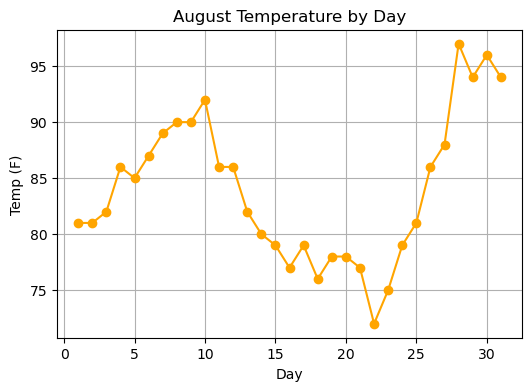

In [28]:
# Line plot of 'Temp' across days for August (8) ordered by Day
plt.figure(figsize=(6, 4))
august = df[df['Month'] == 8].sort_values('Day')
plt.plot(august['Day'], august['Temp'], marker='o', color='orange', linestyle='-')
plt.title('August Temperature by Day')
plt.xlabel('Day')
plt.ylabel('Temp (F)')
plt.grid(True)
plt.show()